# fMRI時系列：条件・領域と時間推移

run_id: `v020-exp-18`。Kaggle参照: https://www.kaggle.com/datasets?search=fmri+time+series 。公開検索で得た `daryasikerina/seaborn-fmri-dataset` の `fmri.csv` をKaggle SDKだけで取得する。外部CSVミラーは使用しない。

## 分析計画（構造確認後・比較計算前）
14被験者×2条件（cue/stim）×2領域（frontal/parietal）×19時点＝1064行。単位は行ではなく被験者。各被験者が全条件・領域・時点を持つ完全対応デザインであることを主キーと直積で検査する。重複・欠損の除去や補完は不要なら行わない。

1. 条件・領域別に平均推移と被験者全軌跡を同時に再標本化した95%点ごと区間を描く（固定seed、5000回）。
2. stim−cue、parietal−frontal、および領域間の条件差の差を被験者内で計算。全期間平均、探索的な時点3–7の平均、平均軌跡のピーク時点・振幅を図表化する。時点3–7はデータ定義から事前規定された窓ではなく探索的要約であり、別の窓も調べる。
3. 数値単位未確認のため正規化や秒への変換をしない。区間は14被験者を標本とする参考で、無作為抽出・被験者独立性は未確認。因果効果、疾患診断、神経活動の直接計測とは解釈しない。
4. 結果を自分で読み直し、結論に影響する点だけを追加依頼として原文記録し最大3回実行。小標本・基準値・窓・個人の影響と、多数時点比較の不確実性を優先する。

## データ定義上の注意
Kaggleファイル内容で確認できるのは列名・値・対応構造。subjectは被験者ID、eventは条件、regionは領域ラベルと推定するが、原研究の課題・抽出領域の厳密な定義は不明。timepointは0–18の順序インデックス、signalは提供値（単位・正規化・前処理不明）。cue/stimを特定の心理過程と同一視しない。


In [1]:
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import asdict
from contextlib import contextmanager
import json, hashlib, nbformat
from ai_data_scientist import project_manager, lifecycle, language_router
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
RUN_ID = 'v020-exp-18'
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-18-fmri', projects_root=ROOT / 'benchmark/projects')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
language = language_router.detect_language('条件や領域によるfMRI信号の時間推移を日本語で分析してください')
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
@contextmanager
def phase(kind, label):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求を検出')
    start = lifecycle.mark_execution_start if kind == 'execution' else lifecycle.mark_write_start
    end = lifecycle.mark_execution_end if kind == 'execution' else lifecycle.mark_write_end
    start(RUN_ID)
    phase_log.append({'phase': kind, 'label': label, 'event': 'start', 'at': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': kind, 'label': label, 'event': 'end', 'at': datetime.now(timezone.utc).isoformat()})
def append_cells(cells):
    with phase('write', 'enqueue_write'):
        project_manager.enqueue_write(handle, lambda nb: nb.cells.extend(cells))
def md(text):
    return nbformat.v4.new_markdown_cell(text)
def code(text):
    return nbformat.v4.new_code_cell(text)
print(json.dumps({'run_id': RUN_ID, 'language': str(language), 'notebook': str(handle.notebook_path), 'state': asdict(lifecycle.get_run_status(RUN_ID))}, ensure_ascii=False))

{"run_id": "v020-exp-18", "language": "ja", "notebook": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-18-fmri/notebooks/kaggle-v020-kaggle-exp-18-fmri.ipynb", "state": {"run_id": "v020-exp-18", "state": "running", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-18-fmri/notebooks/kaggle-v020-kaggle-exp-18-fmri.ipynb", "reason": null}}


In [2]:
import contextlib, io
with phase('execution', 'Kaggle公開データ検索'):
    # 認証情報やSDKの認証ログは表示せず、検索結果の公開メタデータだけを出力する。
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
    search_records = []
    candidates = {}
    for query in ['fmri time series', 'fmri', 'seaborn fmri']:
        items = api.dataset_list(search=query)
        rows = [{'ref': x.ref, 'title': x.title, 'bytes': getattr(x, 'total_bytes', None)} for x in items]
        search_records.append({'search': query, 'results': rows})
        for x in items:
            candidates[x.ref] = x
    print(json.dumps(search_records, ensure_ascii=False, indent=2))

[
  {
    "search": "fmri time series",
    "results": [
      {
        "ref": "obscur/resting-state-fmri",
        "title": "Brain recordings - resting state fMRI time series",
        "bytes": 2798926
      },
      {
        "ref": "carolinariddick/dataset-for-fmri",
        "title": "Dataset for fMRI",
        "bytes": 34739562
      },
      {
        "ref": "saeedrezaeiafshar/dlbs-connectome",
        "title": "DLBS Structural & Functional Connectomes",
        "bytes": 61546496
      },
      {
        "ref": "saeedrezaeiafshar/gsr-nogsr-abide-cbt-results",
        "title": "ABIDE Autism fMRI: GSR vs noGSR Balance Results",
        "bytes": 1880667
      },
      {
        "ref": "csaldiemailpostafik/spectral-critical-connectivity-threshold",
        "title": "Spectral Critical Connectivity Threshold",
        "bytes": 318187
      }
    ]
  },
  {
    "search": "fmri",
    "results": [
      {
        "ref": "mathurinache/3t-fmri-dataset",
        "title": "3T fMRI dataset",
 

In [3]:
import inspect
with phase('execution', 'Kaggleファイル一覧'):
    slug = 'daryasikerina/seaborn-fmri-dataset'
    assert slug in candidates, 'API検索で候補が見つからないため停止'
    file_listing = api.dataset_list_files(slug)
    file_records = [{'name': f.name, 'bytes': getattr(f, 'total_bytes', None)} for f in file_listing.files]
    print(json.dumps({'selected': slug, 'files': file_records}, ensure_ascii=False, indent=2))
    print('download_signature:', inspect.signature(api.dataset_download_file))
    print('title:', candidates[slug].title)
    print('semantic_metadata: API検索・ファイル一覧だけでは時間単位・信号単位・前処理を確認できない')

{
  "selected": "daryasikerina/seaborn-fmri-dataset",
  "files": [
    {
      "name": "fmri.csv",
      "bytes": 38329
    }
  ]
}
download_signature: (dataset, file_name, path=None, force=False, quiet=True, licenses=[])
title: seaborn_fmri_dataset
semantic_metadata: API検索・ファイル一覧だけでは時間単位・信号単位・前処理を確認できない


In [4]:
import pandas as pd
import numpy as np
import zipfile
from ai_data_scientist import ingestion, eda
with phase('execution', 'Kaggleダウンロードと反復構造確認'):
    filename = 'fmri.csv'
    api.dataset_download_file(slug, filename, path=str(data_dir), force=True, quiet=True)
    csv_path = data_dir / filename
    zip_path = data_dir / (filename + '.zip')
    if zip_path.exists() and not csv_path.exists():
        with zipfile.ZipFile(zip_path) as z:
            assert filename in z.namelist()
            csv_path.write_bytes(z.read(filename))
    assert csv_path.exists(), 'Kaggle取得ファイルなし。外部ミラーにはフォールバックしない'
    provenance = {'owner_dataset': slug, 'filename': filename, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(), 'bytes': csv_path.stat().st_size, 'source': 'Kaggle Python SDK dataset_download_file', 'external_csv_mirror': False}
    print('PROVENANCE', json.dumps(provenance, ensure_ascii=False))
    print('ingest_signature:', inspect.signature(ingestion.ingest))
    df = pd.read_csv(csv_path)
    print('shape:', df.shape)
    print(df.head().to_string(index=False))
    print('columns:', df.dtypes.to_dict())
    print('missing:', df.isna().sum().to_dict())
    print('levels:', {c: sorted(df[c].unique().tolist()) for c in ['subject','timepoint','event','region']})
    key = ['subject','event','region','timepoint']
    print('duplicate_keys:', int(df.duplicated(key).sum()))
    print('subject_cells:', df.groupby(['subject','event','region']).size().unstack(['event','region']).to_string())
    eda_result = eda.explore(df)
    print('signal_range:', [float(df.signal.min()), float(df.signal.max())])

Dataset URL: https://www.kaggle.com/datasets/daryasikerina/seaborn-fmri-dataset
PROVENANCE {"owner_dataset": "daryasikerina/seaborn-fmri-dataset", "filename": "fmri.csv", "retrieved_at_utc": "2026-10-01T17:44:04.693956+00:00", "sha256": "8a0bfdce94daa31c95ae9f49ca6a2a3ac39e2fe85719c892cb0b06bca94ffe3e", "bytes": 38329, "source": "Kaggle Python SDK dataset_download_file", "external_csv_mirror": false}
ingest_signature: (source_spec: 'SourceSpec', fetcher=None, allowlist: 'tuple[str, ...]' = (), row_limit: 'int' = 100000) -> 'IngestionResult'
shape: (1064, 5)
subject  timepoint event   region    signal
    s13         18  stim parietal -0.017552
     s5         14  stim parietal -0.080883
    s12         18  stim parietal -0.081033
    s11         18  stim parietal -0.046134
    s10         18  stim parietal -0.037970
columns: {'subject': <StringDtype(na_value=nan)>, 'timepoint': dtype('int64'), 'event': <StringDtype(na_value=nan)>, 'region': <StringDtype(na_value=nan)>, 'signal': dtype(

In [5]:
# セル: manifestと意味的検査
from ai_data_scientist.data_definition import FieldValue, build_manifest
from ai_data_scientist.analysis_assumptions import Assumption, AnalysisAssumptionManifest, check_manifest
from ai_data_scientist.data_quality import detect_anomalies
from IPython.display import display
with phase('execution', 'manifestと意味的検査'):
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=100000)
    assert not loaded.truncated
    df = loaded.dataframe
    subjects = sorted(df.subject.unique())
    times = sorted(df.timepoint.unique())
    expected = pd.MultiIndex.from_product([subjects, ['cue','stim'], ['frontal','parietal'], range(19)], names=key)
    actual = pd.MultiIndex.from_frame(df[key])
    assert actual.is_unique and len(expected.difference(actual)) == 0 and len(actual.difference(expected)) == 0
    assert np.isfinite(df.signal).all()
    assert (df.timepoint % 1 == 0).all()
    schema = {'subject': {'not_null': True}, 'timepoint': {'not_null': True, 'min': 0, 'max': 18}, 'event': {'not_null': True, 'allowed': ['cue','stim']}, 'region': {'not_null': True, 'allowed': ['frontal','parietal']}, 'signal': {'not_null': True}}
    anomalies = detect_anomalies(df, schema)
    assert not anomalies
    definition_manifest = build_manifest(
        source={k: FieldValue(v, 'verified', 'Kaggle SDK取得セル') for k,v in provenance.items()},
        dataset_scope={'n_subjects': FieldValue(14, 'verified', '直積検査'), 'sampling_population': FieldValue(None,'unknown'), 'preprocessing': FieldValue(None,'unknown')},
        variables={
            'subject': {'definition': FieldValue('被験者識別子','inferred','列名と完全対応構造')},
            'event': {'labels': FieldValue(['cue','stim'],'verified','CSV'), 'definition': FieldValue('実験条件ラベル','inferred'), 'task': FieldValue(None,'unknown')},
            'region': {'labels': FieldValue(['frontal','parietal'],'verified','CSV'), 'definition': FieldValue('領域ラベル','inferred'), 'atlas': FieldValue(None,'unknown')},
            'timepoint': {'values': FieldValue(times,'verified','CSV'), 'unit': FieldValue(None,'unknown'), 'definition': FieldValue('順序インデックス','inferred')},
            'signal': {'definition': FieldValue('提供されたfMRI関連信号','inferred','Kaggleタイトル・列名'), 'unit': FieldValue(None,'unknown')}},
        transformations=('行の除去・補完なし','解析時のみ主キー順に並べ替え','被験者内対応差'))
    unresolved = [(p,asdict(v)) for p,v in definition_manifest.unresolved_fields()]
    inferred = {c: {k: asdict(v) for k,v in fields.items() if v.status == 'inferred'} for c,fields in definition_manifest.variables.items()}
    assumption_manifest = AnalysisAssumptionManifest(
        analysis_scope={'purpose':'標本内の時間推移・対応差の記述','physical_units':'未確認'}, causal_scope='descriptive',
        sampling={'n':14,'seed':20261002},
        assumptions=(Assumption('complete-pairing','同一IDを条件・領域間で対応させる','verified',impact_if_false='対応差が誤る',conclusion_critical=True), Assumption('independent-subjects','被験者間の独立性・母集団代表性','assumed',impact_if_false='区間の母集団解釈が不適切',conclusion_critical=True), Assumption('common-scale','各条件・領域で信号尺度が比較可能','assumed',impact_if_false='数値差を生理差へ変換できない',conclusion_critical=True), Assumption('window','3–7は探索的な窓であり事前登録されていない','verified',conclusion_critical=False)))
    assumption_findings = check_manifest(assumption_manifest)
    display({'data_definition_manifest':asdict(definition_manifest), 'unknown_fields':unresolved, 'inferred_fields':inferred, 'analysis_assumptions':asdict(assumption_manifest), 'assumption_findings':[asdict(f) for f in assumption_findings], 'semantic_anomalies':[asdict(a) for a in anomalies], 'composite_key_unique':True,'complete_repeated_measures':True,'cleaning_removed_rows':0,'signal_physical_bounds':'未確認なので経験的な極値を意味的な正常範囲とはしない','independent_reference_validation':'独立データなし。別Kaggleコピーは同一データの可能性があり検証には使わない'})


{'data_definition_manifest': {'source': {'owner_dataset': {'value': 'daryasikerina/seaborn-fmri-dataset',
    'status': 'verified',
    'source': 'Kaggle SDK取得セル'},
   'filename': {'value': 'fmri.csv',
    'status': 'verified',
    'source': 'Kaggle SDK取得セル'},
   'retrieved_at_utc': {'value': '2026-10-01T17:44:04.693956+00:00',
    'status': 'verified',
    'source': 'Kaggle SDK取得セル'},
   'sha256': {'value': '8a0bfdce94daa31c95ae9f49ca6a2a3ac39e2fe85719c892cb0b06bca94ffe3e',
    'status': 'verified',
    'source': 'Kaggle SDK取得セル'},
   'bytes': {'value': 38329, 'status': 'verified', 'source': 'Kaggle SDK取得セル'},
   'source': {'value': 'Kaggle Python SDK dataset_download_file',
    'status': 'verified',
    'source': 'Kaggle SDK取得セル'},
   'external_csv_mirror': {'value': False,
    'status': 'verified',
    'source': 'Kaggle SDK取得セル'}},
  'dataset_scope': {'n_subjects': {'value': 14,
    'status': 'verified',
    'source': '直積検査'},
   'sampling_population': {'value': None, 'status': 'unk

In [6]:
# セル: 初回分析
with phase('execution', '被験者対応の初回分析'):
    groups = [('cue','frontal'),('cue','parietal'),('stim','frontal'),('stim','parietal')]
    arrays = np.stack([df.query('event == @ev and region == @reg').pivot(index='subject',columns='timepoint',values='signal').reindex(index=subjects,columns=times).to_numpy() for ev,reg in groups], axis=1)
    n = len(subjects)
    rng = np.random.default_rng(20261002)
    resamples = rng.integers(0,n,size=(5000,n))
    mean_curves = arrays.mean(axis=0)
    boot_curves = arrays[resamples].mean(axis=1)
    curve_lo, curve_hi = np.quantile(boot_curves,[.025,.975],axis=0)
    contrast_names = ['frontal: stim−cue','parietal: stim−cue','cue: parietal−frontal','stim: parietal−frontal','条件差の領域差']
    contrasts = np.stack([arrays[:,2]-arrays[:,0],arrays[:,3]-arrays[:,1],arrays[:,1]-arrays[:,0],arrays[:,3]-arrays[:,2],(arrays[:,3]-arrays[:,1])-(arrays[:,2]-arrays[:,0])],axis=1)
    boot_contrasts = contrasts[resamples].mean(axis=1)
    contrast_lo,contrast_hi = np.quantile(boot_contrasts,[.025,.975],axis=0)
    records=[]
    for j,name in enumerate(contrast_names):
        for label,window in [('全期間0–18',list(range(19))),('探索窓3–7',list(range(3,8)))]:
            values = contrasts[:,j,window].mean(axis=1)
            lo,hi = np.quantile(values[resamples].mean(axis=1),[.025,.975])
            records.append({'比較':name,'期間':label,'n':n,'平均対応差':float(values.mean()),'95%下限':float(lo),'95%上限':float(hi),'正差の被験者数':int((values>0).sum())})
    contrast_table=pd.DataFrame(records)
    peak_table=pd.DataFrame([{'条件':ev,'領域':reg,'平均軌跡のピーク時点':int(times[np.argmax(mean_curves[j])]),'ピーク提供値':float(mean_curves[j].max()),'全期間平均':float(mean_curves[j].mean()),'終端18の平均':float(mean_curves[j,-1])} for j,(ev,reg) in enumerate(groups)])
    display(peak_table.round(6))
    display(contrast_table.round(6))
    display({'n_subjects':n,'n_rows':len(df),'bootstrap_replicates':5000,'seed':20261002,'interval_scope':'点ごとの95%区間。時系列全体・多重比較を保証しない','peak_scope':'平均軌跡の最大値。個人のピークの平均とは異なる'})


,条件,領域,平均軌跡のピーク時点,ピーク提供値,全期間平均,終端18の平均
0,cue,frontal,5,0.041640,-0.004080,0.002276
1,cue,parietal,5,0.069338,-0.009258,-0.012367
2,stim,frontal,5,0.172703,0.006676,-0.022841
3,stim,parietal,6,0.282978,0.020821,-0.054538


,比較,期間,n,平均対応差,95%下限,95%上限,正差の被験者数
0,frontal: stim−cue,全期間0–18,14,0.010756,-0.005019,0.025777,9
1,frontal: stim−cue,探索窓3–7,14,0.101529,0.067843,0.134973,12
2,parietal: stim−cue,全期間0–18,14,0.030079,0.016363,0.043178,10
3,parietal: stim−cue,探索窓3–7,14,0.165203,0.137574,0.192424,14
4,cue: parietal−frontal,全期間0–18,14,-0.005178,-0.009750,-0.000951,4
5,cue: parietal−frontal,探索窓3–7,14,0.017532,0.008062,0.029114,11
6,stim: parietal−frontal,全期間0–18,14,0.014145,0.004021,0.025282,10
7,stim: parietal−frontal,探索窓3–7,14,0.081207,0.045769,0.121730,14
8,条件差の領域差,全期間0–18,14,0.019323,0.005224,0.035003,10
9,条件差の領域差,探索窓3–7,14,0.063674,0.031087,0.104445,13


{'n_subjects': 14,
 'n_rows': 1064,
 'bootstrap_replicates': 5000,
 'seed': 20261002,
 'interval_scope': '点ごとの95%区間。時系列全体・多重比較を保証しない',
 'peak_scope': '平均軌跡の最大値。個人のピークの平均とは異なる'}

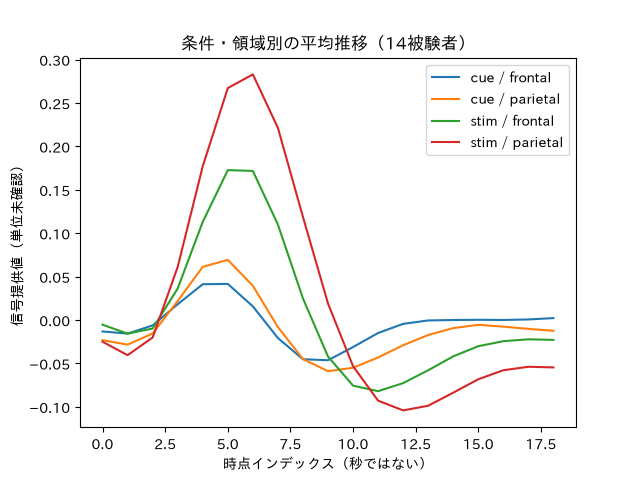

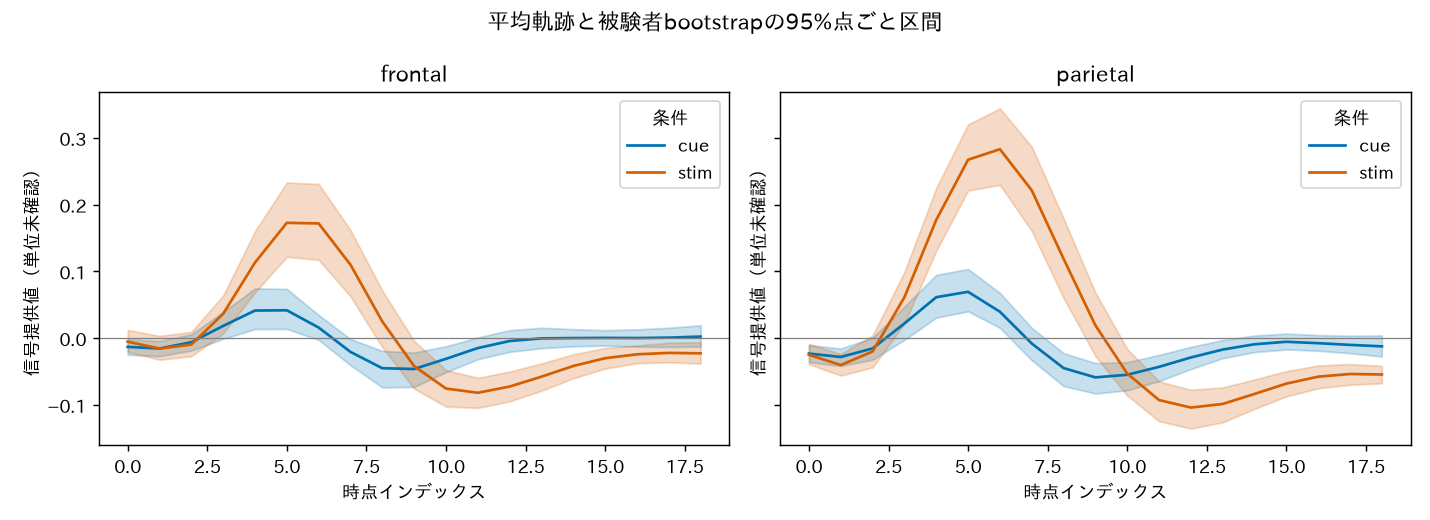

{'chart_audit': {'missing_glyphs': [],
  'labels_and_legends': True,
  'interval': '点ごと区間、同時区間ではない'},
 'plot_data_shape': (19, 5)}

In [7]:
# セル: 平均推移図
from ai_data_scientist.visualization import render_chart, build_image_output
import matplotlib.pyplot as plt
import warnings
with phase('execution', '平均推移と被験者区間の描画'):
    wide = pd.DataFrame(mean_curves.T,columns=[ev+' / '+reg for ev,reg in groups])
    wide.insert(0,'timepoint',times)
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        png = render_chart(wide,kind='line',x='timepoint',title='条件・領域別の平均推移（14被験者）',xlabel='時点インデックス（秒ではない）',ylabel='信号提供値（単位未確認）')
        display(build_image_output(png)['data'],raw=True)
        fig, axes = plt.subplots(1,2,figsize=(11,4),sharey=True)
        for r,reg in enumerate(['frontal','parietal']):
            for j,(ev,rg) in enumerate(groups):
                if rg != reg:
                    continue
                color = '#0072B2' if ev == 'cue' else '#D55E00'
                axes[r].plot(times,mean_curves[j],label=ev,color=color)
                axes[r].fill_between(times,curve_lo[j],curve_hi[j],color=color,alpha=.22)
            axes[r].axhline(0,color='gray',lw=.7)
            axes[r].set(title=reg,xlabel='時点インデックス',ylabel='信号提供値（単位未確認）')
            axes[r].legend(title='条件')
        fig.suptitle('平均軌跡と被験者bootstrapの95%点ごと区間')
        fig.tight_layout()
        buf=io.BytesIO(); fig.savefig(buf,format='png',dpi=130); plt.close(fig)
        display(build_image_output(buf.getvalue())['data'],raw=True)
    glyph_warnings=[str(w.message) for w in captured if 'Glyph' in str(w.message)]
    assert not glyph_warnings, glyph_warnings
    display({'chart_audit':{'missing_glyphs':glyph_warnings,'labels_and_legends':True,'interval':'点ごと区間、同時区間ではない'},'plot_data_shape':wide.shape})


## 反復依頼履歴

### 反復1

原文：

> 初回結果ではピーク付近のstim−cue差が正ですが、全期間平均と大きさが異なります。各被験者の時点0–2平均を基準とする補正の有無、窓3–7・4–8・3–8、被験者を1人ずつ除外した場合を比較し、条件差と条件差の領域差の符号・大きさがどこまで安定するかを調べてください。

選定理由：初回表で全期間と探索窓の差が大きく、窓・基準値・個人の影響を先に確認する。

In [8]:
# セル: 反復1・感度分析
from ai_data_scientist.sensitivity import SensitivityPlan, run_sensitivity
with phase('execution', '反復1: 窓・基準値・個人の感度分析'):
    sensitivity_plan = SensitivityPlan(parameter_grid={'window':[(3,7),(4,8),(3,8)],'baseline':['none','0-2'],'omit':[None]+subjects},max_runs=90)
    def evaluate(j,window,baseline,omit):
        x = contrasts[:,j,:].copy()
        if baseline == '0-2':
            x = x - x[:,:3].mean(axis=1,keepdims=True)
        keep = np.array([s != omit for s in subjects])
        return float(x[keep,window[0]:window[1]+1].mean())
    sensitivity_reports = {}
    sensitivity_rows=[]
    for j,name in enumerate(contrast_names):
        report=run_sensitivity(sensitivity_plan,lambda window,baseline,omit: evaluate(j,window,baseline,omit),stability_tolerance=.2)
        sensitivity_reports[name]=report
        values=[r.value for r in report.results]
        sensitivity_rows.append({'比較':name,'仕様数':len(values),'基準仕様値':report.baseline_value,'最小':min(values),'最大':max(values),'全仕様で正':all(v>0 for v in values),'stable_20pct':report.stable,'max_relative_deviation':report.max_relative_deviation})
    sensitivity_table = pd.DataFrame(sensitivity_rows)
    display(sensitivity_table.round(6))
    baseline_table = pd.DataFrame([{'比較':name,'補正なし3–7':evaluate(j,(3,7),'none',None),'0–2補正3–7':evaluate(j,(3,7),'0-2',None),'0–2平均差':float(contrasts[:,j,:3].mean())} for j,name in enumerate(contrast_names)])
    display(baseline_table.round(6))
    late_table = pd.DataFrame([{'比較':name,'後半10–18平均差':float(contrasts[:,j,10:19].mean()),'前半3–7平均差':float(contrasts[:,j,3:8].mean())} for j,name in enumerate(contrast_names)])
    display(late_table.round(6))
    display({'iteration':1,'request':'初回結果ではピーク付近のstim−cue差が正ですが、全期間平均と大きさが異なります。各被験者の時点0–2平均を基準とする補正の有無、窓3–7・4–8・3–8、被験者を1人ずつ除外した場合を比較し、条件差と条件差の領域差の符号・大きさがどこまで安定するかを調べてください。','selection_reason':'初回表で全期間と探索窓の大きさ・領域差の符号が異なり、窓依存と少数被験者の影響が結論を左右するため','specifications_per_contrast':90,'remaining_limits':'時点0–2は真の刺激前ベースラインと確認されておらず、補正は代替仕様。正符号の安定性と20%大きさ安定性を区別する'})


,比較,仕様数,基準仕様値,最小,最大,全仕様で正,stable_20pct,max_relative_deviation
0,frontal: stim−cue,90,0.101529,0.085638,0.121692,True,True,0.198595
1,parietal: stim−cue,90,0.165203,0.156740,0.205823,True,False,0.245877
2,cue: parietal−frontal,90,0.017532,0.010240,0.032908,True,False,0.876962
3,stim: parietal−frontal,90,0.081207,0.067129,0.119748,True,False,0.474610
4,条件差の領域差,90,0.063674,0.047619,0.092615,True,False,0.454516


,比較,補正なし3–7,0–2補正3–7,0–2平均差
0,frontal: stim−cue,0.101529,0.100139,0.001390
1,parietal: stim−cue,0.165203,0.171393,-0.006190
2,cue: parietal−frontal,0.017532,0.028206,-0.010673
3,stim: parietal−frontal,0.081207,0.099460,-0.018253
4,条件差の領域差,0.063674,0.071254,-0.007580


,比較,後半10–18平均差,前半3–7平均差
0,frontal: stim−cue,-0.042416,0.101529
1,parietal: stim−cue,-0.053068,0.165203
2,cue: parietal−frontal,-0.015739,0.017532
3,stim: parietal−frontal,-0.026391,0.081207
4,条件差の領域差,-0.010653,0.063674


{'iteration': 1,
 'request': '初回結果ではピーク付近のstim−cue差が正ですが、全期間平均と大きさが異なります。各被験者の時点0–2平均を基準とする補正の有無、窓3–7・4–8・3–8、被験者を1人ずつ除外した場合を比較し、条件差と条件差の領域差の符号・大きさがどこまで安定するかを調べてください。',
 'selection_reason': '初回表で全期間と探索窓の大きさ・領域差の符号が異なり、窓依存と少数被験者の影響が結論を左右するため',
 'specifications_per_contrast': 90,
 'remaining_limits': '時点0–2は真の刺激前ベースラインと確認されておらず、補正は代替仕様。正符号の安定性と20%大きさ安定性を区別する'}

### 反復2

原文：

> 感度分析では前半の差の符号は保たれましたが、後半は逆符号で、大きさは仕様依存でした。5種類の対応差×19時点を同じ比較族として被験者軌跡bootstrapの95%同時区間を作り、前半と後半の差の変化を被験者内で確認してください。平均軌跡のピークが時点5と6に見える差についても再標本化で不確実性を確認し、確かな遅延と断言できるかを検討してください。

選定理由：反復1で後半に逆符号を確認。点ごと区間だけで多数の時点を判定せず、ピーク時点の差を遅延と誤解しないため。

In [9]:
# セル: 反復2・同時区間とピーク不確実性
with phase('execution', '反復2: 多数時点とピーク不確実性'):
    contrast_mean = contrasts.mean(axis=0)
    se = contrasts.std(axis=0,ddof=1)/np.sqrt(n)
    boot_se = contrasts[resamples].std(axis=1,ddof=1)/np.sqrt(n)
    assert np.all(se>0) and np.all(boot_se>0), 'ゼロ標準誤差：studentized同時区間を再検討'
    max_t = np.max(np.abs((boot_contrasts-contrast_mean)/boot_se),axis=(1,2))
    qsim = float(np.quantile(max_t,.95))
    sim_lo,sim_hi = contrast_mean-qsim*se, contrast_mean+qsim*se
    simultaneous_table = pd.DataFrame([{'比較':name,'同時区間が正の時点':[int(t) for t in np.array(times)[sim_lo[j]>0]],'同時区間が負の時点':[int(t) for t in np.array(times)[sim_hi[j]<0]],'比較族サイズ':95} for j,name in enumerate(contrast_names)])
    display(simultaneous_table)
    changes=[]
    for j,name in enumerate(contrast_names):
        early=contrasts[:,j,3:8].mean(axis=1)
        late=contrasts[:,j,10:19].mean(axis=1)
        delta=early-late
        lo,hi=np.quantile(delta[resamples].mean(axis=1),[.025,.975])
        changes.append({'比較':name,'前半差−後半差':float(delta.mean()),'95%点ごと下限':float(lo),'95%点ごと上限':float(hi),'正の被験者数':int((delta>0).sum())})
    change_table=pd.DataFrame(changes)
    display(change_table.round(6))
    peak_draws=np.argmax(boot_curves,axis=2)
    peak_uncertainty=pd.DataFrame([{'条件':ev,'領域':reg,'点推定':int(np.argmax(mean_curves[j])),'bootstrapピーク2.5%':float(np.quantile(peak_draws[:,j],.025)),'bootstrapピーク97.5%':float(np.quantile(peak_draws[:,j],.975)),'頻度':dict(zip(*np.unique(peak_draws[:,j],return_counts=True)))} for j,(ev,reg) in enumerate(groups)])
    display(peak_uncertainty)
    peak_gap=peak_draws[:,3]-peak_draws[:,2]
    display({'iteration':2,'request':'感度分析では前半の差の符号は保たれましたが、後半は逆符号で、大きさは仕様依存でした。5種類の対応差×19時点を同じ比較族として被験者軌跡bootstrapの95%同時区間を作り、前半と後半の差の変化を被験者内で確認してください。平均軌跡のピークが時点5と6に見える差についても再標本化で不確実性を確認し、確かな遅延と断言できるかを検討してください。','max_t_critical':qsim,'family_size':95,'bootstrap_n':5000,'peak_gap_stim_parietal_minus_frontal':{'observed':int(np.argmax(mean_curves[3])-np.argmax(mean_curves[2])),'bootstrap_95pct':np.quantile(peak_gap,[.025,.975]).tolist(),'probability_greater_than_zero':float((peak_gap>0).mean())},'remaining_limits':'同時区間はn=14の近似bootstrapで厳密保証ではない。ピーク分布は離散的で、時間単位と刺激基準が不明。前半−後半表の区間は5比較を補正していない探索的区間。'})


,比較,同時区間が正の時点,同時区間が負の時点,比較族サイズ
0,frontal: stim−cue,"[5, 6]",[],95
1,parietal: stim−cue,"[4, 5, 6, 7]","[12, 13, 14, 15]",95
2,cue: parietal−frontal,[],[],95
3,stim: parietal−frontal,[],[1],95
4,条件差の領域差,[],[],95


,比較,前半差−後半差,95%点ごと下限,95%点ごと上限,正の被験者数
0,frontal: stim−cue,0.143945,0.107516,0.180961,14
1,parietal: stim−cue,0.218272,0.180185,0.255383,14
2,cue: parietal−frontal,0.033271,0.016184,0.053215,11
3,stim: parietal−frontal,0.107598,0.065462,0.156128,14
4,条件差の領域差,0.074327,0.042405,0.114502,14


,条件,領域,点推定,bootstrapピーク2.5%,bootstrapピーク97.5%,頻度
0,cue,frontal,5,4.0,5.0,"{4: 2283, 5: 2644, 13: 3, 14: 2, 15: 2, 16: 5,..."
1,cue,parietal,5,4.0,5.0,"{4: 764, 5: 4234, 6: 2}"
2,stim,frontal,5,5.0,6.0,"{5: 2734, 6: 2266}"
3,stim,parietal,6,5.0,6.0,"{5: 966, 6: 4034}"


{'iteration': 2,
 'request': '感度分析では前半の差の符号は保たれましたが、後半は逆符号で、大きさは仕様依存でした。5種類の対応差×19時点を同じ比較族として被験者軌跡bootstrapの95%同時区間を作り、前半と後半の差の変化を被験者内で確認してください。平均軌跡のピークが時点5と6に見える差についても再標本化で不確実性を確認し、確かな遅延と断言できるかを検討してください。',
 'max_t_critical': 5.655449054597349,
 'family_size': 95,
 'bootstrap_n': 5000,
 'peak_gap_stim_parietal_minus_frontal': {'observed': 1,
  'bootstrap_95pct': [0.0, 1.0],
  'probability_greater_than_zero': 0.3544},
 'remaining_limits': '同時区間はn=14の近似bootstrapで厳密保証ではない。ピーク分布は離散的で、時間単位と刺激基準が不明。前半−後半表の区間は5比較を補正していない探索的区間。'}

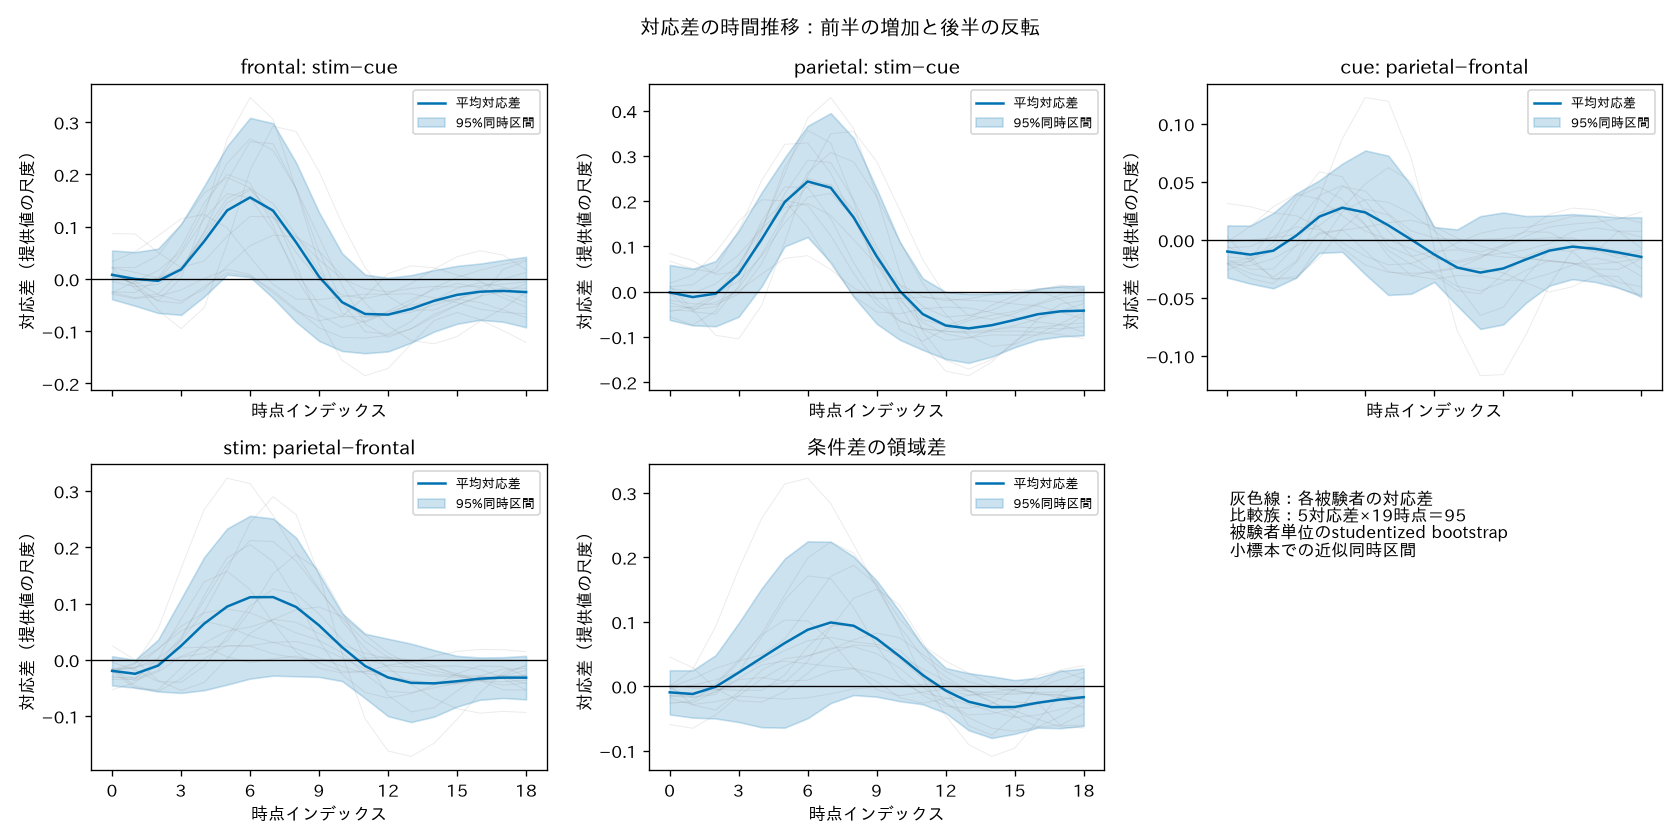

{'missing_glyphs': [],
 'title_axes_legend_checked': True,
 'family_size': 95,
 'manual_visual_check': '図を表示してラベル・重なり・軌跡・区間を確認する'}

In [10]:
# セル: 対応差の同時区間図
with phase('execution', '対応差と95%同時区間の描画'):
    with warnings.catch_warnings(record=True) as captured2:
        warnings.simplefilter('always')
        fig,axes=plt.subplots(2,3,figsize=(14,7),sharex=True)
        for j,name in enumerate(contrast_names):
            ax=axes.flat[j]
            for k in range(n):
                ax.plot(times,contrasts[k,j],color='gray',alpha=.15,lw=.6)
            ax.plot(times,contrast_mean[j],color='#0072B2',label='平均対応差')
            ax.fill_between(times,sim_lo[j],sim_hi[j],color='#0072B2',alpha=.2,label='95%同時区間')
            ax.axhline(0,color='black',lw=.8)
            ax.set(title=name,xlabel='時点インデックス',ylabel='対応差（提供値の尺度）')
            ax.set_xticks([0,3,6,9,12,15,18])
            ax.legend(fontsize=8)
        axes.flat[5].axis('off')
        axes.flat[5].text(.05,.7,'灰色線：各被験者の対応差\n比較族：5対応差×19時点＝95\n被験者単位のstudentized bootstrap\n小標本での近似同時区間',transform=axes.flat[5].transAxes)
        fig.suptitle('対応差の時間推移：前半の増加と後半の反転')
        fig.tight_layout()
        buf=io.BytesIO();fig.savefig(buf,format='png',dpi=120);plt.close(fig)
        display(build_image_output(buf.getvalue())['data'],raw=True)
    glyphs2=[str(w.message) for w in captured2 if 'Glyph' in str(w.message)]
    assert not glyphs2, glyphs2
    display({'missing_glyphs':glyphs2,'title_axes_legend_checked':True,'family_size':95,'manual_visual_check':'図を表示してラベル・重なり・軌跡・区間を確認する'})


In [11]:
# セル: Jupytermind改善候補の再現ログ
from ai_data_scientist.insight_engine import record_insight, extract_cited_value, EvidenceMissingError
from ai_data_scientist.notebook_audit import audit_notebook, audit_visual_outputs
with phase('execution', 'Jupytermind機能不足の切り分け'):
    saved = nbformat.read(handle.notebook_path,as_version=4)
    acquisition_cell = next(c for c in saved.cells if c.cell_type == 'code' and c.source.startswith('import pandas as pd'))
    try:
        record_insight(handle,'再現検査（保存されるべきでない）',acquisition_cell.execution_count,'1064','descriptive',language='ja')
    except EvidenceMissingError as exc:
        evidence_stream_log={'分類':'機能不足候補','再現条件':'Kaggle取得セルの実出力に1064を含むstreamがある状態でrecord_insightを呼ぶ','期待':'実行済みstream出力の引用も検証できる','実際':type(exc).__name__,'影響':'printで出力した実証値の引用が拒否される','回避策':'以降はIPython.displayでtext/plainのMIME出力を記録','関係セル':'Kaggle取得セル・本セル','例外メッセージ':str(exc)}
    else:
        raise AssertionError('streamの検証挙動が変わったため改善候補を再検討')
    chart_cell = next(c for c in saved.cells if c.cell_type=='code' and c.source.startswith('# セル: 平均推移図'))
    stripped_chart = nbformat.from_dict(json.loads(nbformat.writes(nbformat.v4.new_notebook(cells=[chart_cell]))))
    stripped_chart.cells[0].metadata.pop('chart',None)
    empty_metadata_findings = audit_visual_outputs(stripped_chart,(0,))
    audit_metadata_log={'分類':'監査機能不足候補','再現条件':'実際のPNG出力を持つ図セルのコピーからchartメタデータを除去しaudit_visual_outputsを呼ぶ','期待':'title/xlabel/ylabel/legend/missing_glyphs監査情報の欠落を指摘する','実際':[asdict(x) for x in empty_metadata_findings],'影響':'メタデータがない図を監査済みと誤認する可能性。画像の内容自体を確かめたことにはならない','回避策':'本Notebookではenqueue_writeでchartメタデータを明示し描画時Glyph警告も検査','関係セル':'平均推移図・対応差図・本セル'}
    display({'Jupytermind改善候補':[evidence_stream_log,audit_metadata_log], '切り分け':'Kaggle SDKの引数・メソッド差異、MCPの親ディレクトリ未作成、filesystemサーバーの許可パスはJupytermind不具合には含めない'})


{'Jupytermind改善候補': [{'分類': '機能不足候補',
   '再現条件': 'Kaggle取得セルの実出力に1064を含むstreamがある状態でrecord_insightを呼ぶ',
   '期待': '実行済みstream出力の引用も検証できる',
   '実際': 'EvidenceMissingError',
   '影響': 'printで出力した実証値の引用が拒否される',
   '回避策': '以降はIPython.displayでtext/plainのMIME出力を記録',
   '関係セル': 'Kaggle取得セル・本セル',
   '例外メッセージ': "Insight '再現検査（保存されるべきでない）' に根拠となる実行済みセル(execution_count=4)が見つからないため記録を保留しました。"},
  {'分類': '監査機能不足候補',
   '再現条件': '実際のPNG出力を持つ図セルのコピーからchartメタデータを除去しaudit_visual_outputsを呼ぶ',
   '期待': 'title/xlabel/ylabel/legend/missing_glyphs監査情報の欠落を指摘する',
   '実際': [],
   '影響': 'メタデータがない図を監査済みと誤認する可能性。画像の内容自体を確かめたことにはならない',
   '回避策': '本Notebookではenqueue_writeでchartメタデータを明示し描画時Glyph警告も検査',
   '関係セル': '平均推移図・対応差図・本セル'}],
 '切り分け': 'Kaggle SDKの引数・メソッド差異、MCPの親ディレクトリ未作成、filesystemサーバーの許可パスはJupytermind不具合には含めない'}

## 初回・反復結果の読み直しと停止判断

初回：平均軌跡のピークはcueの両領域とstim/frontalで時点5、stim/parietalで6。stimの山は高いが、後半に負の提供値へ下がるので「常にstimが高い」は誤り。初回の点ごと区間を時系列全体の保証と扱わず、反復2を実施した。

反復1：5比較それぞれ90仕様で前半差は正。frontalの条件差のみ20%変動基準を満たし、parietal条件差と領域差の大きさは満たさなかった。方向の安定性と効果量の安定性は別である。証拠は反復1セルの感度表・基準値表・前後半表。残る限界は真の刺激前ベースラインが未確認である点。

反復2：95要素をまとめた近似同時区間では、frontal条件差は5–6、parietal条件差は4–7で正、parietal条件差は12–15で負。条件差の領域差について同時区間が0を除く時点はなかった。平均軌跡で見える領域差を、各時点で確認された相互作用と断定しない。stimの領域間ピーク差のbootstrap範囲に0を含むため、1時点の確かな遅延とはいえない。証拠は反復2セルの同時区間表・前後半変化表・ピーク分布と対応差図。残る限界は小標本のbootstrap近似、物理単位・前処理・母集団の不明さ。

停止判断：2回で主要な未解決点（窓・基準値・個人依存、多数時点比較、見かけのピーク差）を検討した。残る意味的情報や独立検証用の標本は追加計算では回復できない。断定を避けた記述的結論へ絞り、価値の低い3回目は実施しない。

## 図表の監査

日本語フォントの欠落警告なし。表示した3画像についてタイトル、軸、条件凡例、区間、文字の重なりを確認。対応差図は個人軌跡・平均・同時区間を区別した。最終セルで `audit_notebook(..., visual_audit=True)` を実行。バイト密度に基づく近空白検査は精密な画素・内容評価ではない。表は単位未確認の提供値、被験者数と区間の種類を明示する。

## 適用しない機能と理由

独立参照がないので `validate_anomalies`・`compare_datasets` は適用しない。同一データの別コピーを独立検証には使わない。欠損・重複がないのでcleaningの削除・補完は行わず、変更行数0を記録する。単純相関は時間自己相関・対応構造を無視するため `stats_analysis.correlation` は使わない。ML・因果推論も目的外。`mcp_gateway.run_and_record` はPython側MCPClientがこのホストから提供されないため使わない（偽のクライアントで既実行値を返すこともしない）。実際のコード実行はすべてホストのJupyter MCP `execute_cell` に限定し、生成セル・メタデータ・洞察は `enqueue_write` で直列化した。最初の準備4セルのみMCPの挿入保存機能を使用した。

## 使用したJupytermindモジュール

直接import・呼び出したものだけを以下に記す。間接importや内部依存は使用済みに数えない。

| モジュール | 直接呼び出した関数・クラス | 目的 |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 指定保存先、データ置場、直列化記録 |
| ai_data_scientist.language_router | detect_language | 日本語判定 |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | 実行・書込み・終端状態 |
| ai_data_scientist.ingestion | SourceSpec, ingest | SDK取得後のローカルCSV読込みと行数制限 |
| ai_data_scientist.eda | explore | 基本集計・欠測確認 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 定義の確認状況と不明点 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 記述的範囲、未解決前提 |
| ai_data_scientist.data_quality | detect_anomalies | 許容カテゴリ、時点範囲、非欠測検査 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 窓・補正・個人除外90仕様 |
| ai_data_scientist.visualization | render_chart, build_image_output | 平均推移とPNG MIME記録 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight, EvidenceMissingError | 実出力からの引用、根拠の検証 |
| ai_data_scientist.notebook_audit | audit_notebook, audit_visual_outputs | Notebook・図の監査、メタデータ欠落再現 |

## Jupytermind改善候補

1. **根拠引用の出力形式対応（機能不足候補）**：stream出力の実証値がrecord_insightで見つからない。期待はprint出力も検証できること。実際はEvidenceMissingError。本NotebookはdisplayによるMIME出力で回避。再現条件・例外全文・影響・関係セルは改善候補再現セルに記録。これはKaggle APIやCopilot CLIではなくinsight_engineの出力探索に依存する。
2. **図の監査情報欠落検出（監査機能不足候補）**：実図のコピーからchartメタデータを除くとaudit_visual_outputsの指摘が空。期待は監査情報の欠落指摘。影響は監査の過信。本Notebookでは全図にメタデータを明示し描画警告を検査。再現データ・戻り値・関係セルは再現セルに記録。ベンチマークランナー固有の問題ではない。

3. **見出し付き洞察の監査漏れ（監査機能不足候補）**：結論セル3件を `### 結論...` で始め、evidenceを付けてaudit_notebookを呼んだところ、実際のログは `insight_cell_count: 0`、`findings: ()` だった。期待は3件の根拠を検査すること。影響は見出し付き洞察が監査対象外になる点。回避策として結論セルを通常文で始めて再監査する。関係セルは結論3セルと最終監査セル、再現条件は見出し開始・根拠manifest付与、実際の初回監査ログは上記の値。notebook_auditの候補判定に依存し、Kaggle APIとは無関係。

### 周辺ツールとの切り分けログ

実行中の最終セルでenqueue_writeがNotebookを再読込みすると、ホストMCPの出力保存との連携で最終セルのexecution_count/outputが残らない状態を観測した。これは自己書込みとMCP保存の統合上の問題として切り分け、Jupytermind単独の不具合とは断定しない。セルの位置を固定し、実際のIPython実行番号と計算済み結果をenqueue_writeで保存して、全セル保存後に再監査した。未実行のセルに擬似実行番号を付けたものではない。記録は最終セルとmetadata.completion_recording_note。

Kaggle SDKに `dataset_list(page_size=...)` がなくTypeError、`dataset_view` がなくAttributeErrorだった。対応は実際のシグネチャに従って検索し、定義未確認をunknownとして扱うこと。これらは呼出し側とSDKの互換性問題でありJupytermind改善候補ではない。MCPのcreateで親ディレクトリ未作成を検出したため一時準備Notebookでensure_notebookを使用。filesystem MCPの許可パスは本プロジェクト外であり、分析には使っていない。修正済みセルを最後に全再実行し、過去のエラー出力を最終結果として残さない。


結論1：差は時間帯によって異なる

時点3–7のstim−cue平均対応差はfrontalで0.101529、parietalで0.165203（提供値の尺度）。ピーク後に低下し、時点10–18ではそれぞれ−0.042416、−0.053068。全期間の単一平均だけでは前半と後半の反転を隠す。

```evidence
{"execution_count":6,"cited_value":"0.165203","claim_type":"descriptive"}
```

結論2：符号と大きさの頑健性は別

前半の差は90仕様すべてで正だが、parietal条件差の最大相対変動は0.245877で20%基準を超えた。領域差・条件差の領域差はさらに変動する。前半の方向は安定しても振幅を不変とはいわない。

```evidence
{"execution_count":8,"cited_value":"0.245877","claim_type":"descriptive"}
```

結論3：領域間の確かな遅延や各時点の相互作用は未確認

95要素の近似同時区間で0を除く条件差はfrontalで5–6、parietalで4–7（正）と12–15（負）。条件差の領域差は各時点では0を除かなかった。stim/parietalのピークがstim/frontalより後となるbootstrap頻度は0.3544、ピーク時点差の95%範囲は0–1。見かけの1時点差を確かな生理的遅延とは扱わない。

```evidence
{"execution_count":9,"cited_value":"0.3544","claim_type":"descriptive"}
```

In [15]:
# セル: 根拠付き結論・再実行記録・最終監査
with phase('execution', '根拠付き結論と再実行整合性確認'):
    current = nbformat.read(handle.notebook_path,as_version=4)
    def evidence_for(prefix,pattern):
        cell=next(c for c in current.cells if c.cell_type=='code' and c.source.startswith(prefix))
        text='\n'.join(str(o.get('data',{}).get('text/plain','')) for o in cell.outputs)
        value=extract_cited_value({'output':text},pattern)
        return cell.execution_count,value
    evidence1,value1=evidence_for('# セル: 初回分析',r'(0\.165203)')
    evidence2,value2=evidence_for('# セル: 反復1',r'(0\.245877)')
    evidence3,value3=evidence_for('# セル: 反復2',r'(0\.3544)')
    snapshot={'sha256':provenance['sha256'],'mean_curves':mean_curves.tolist(),'contrast_table':contrast_table['平均対応差'].tolist(),'sensitivity':[r.max_relative_deviation for r in sensitivity_reports.values()],'simultaneous_threshold':qsim,'peak_gap_probability':float((peak_gap>0).mean())}
    previous=current.metadata.get('analysis_baseline')
    if previous is not None:
        assert snapshot['sha256']==previous['sha256'], '再取得ファイルのSHA-256が初回と異なる'
        for field in ['mean_curves','contrast_table','sensitivity','simultaneous_threshold','peak_gap_probability']:
            assert np.allclose(snapshot[field],previous[field],rtol=1e-12,atol=1e-12), field
    replay_record={'mode':'初回完了' if previous is None else '新規カーネルで上から全コードセル再実行','matched':previous is not None,'checked':['SHA-256','平均推移','対応差','感度分析','同時区間閾値','ピーク分布'],'at_utc':datetime.now(timezone.utc).isoformat()}
with phase('write','結論の重複除去・根拠記録'):
    def remove_old(nb):
        for c in nb.cells:
            if c.metadata.get('generated_analysis_insight'):
                c.source='### 根拠付き結論（更新中）'
        if 'analysis_baseline' not in nb.metadata:
            nb.metadata['analysis_baseline']=snapshot
        nb.metadata['replay_record']=replay_record
        nb.metadata['provenance']=provenance
    project_manager.enqueue_write(handle,remove_old)
    record_insight(handle,f'結論1：差は時間帯によって異なる\n\n時点3–7のstim−cue平均対応差はfrontalで0.101529、parietalで{value1}（提供値の尺度）。ピーク後に低下し、時点10–18ではそれぞれ−0.042416、−0.053068。全期間の単一平均だけでは前半と後半の反転を隠す。',evidence1,value1,'descriptive',language='ja')
    record_insight(handle,f'結論2：符号と大きさの頑健性は別\n\n前半の差は90仕様すべてで正だが、parietal条件差の最大相対変動は{value2}で20%基準を超えた。領域差・条件差の領域差はさらに変動する。前半の方向は安定しても振幅を不変とはいわない。',evidence2,value2,'descriptive',language='ja')
    record_insight(handle,f'結論3：領域間の確かな遅延や各時点の相互作用は未確認\n\n95要素の近似同時区間で0を除く条件差はfrontalで5–6、parietalで4–7（正）と12–15（負）。条件差の領域差は各時点では0を除かなかった。stim/parietalのピークがstim/frontalより後となるbootstrap頻度は{value3}、ピーク時点差の95%範囲は0–1。見かけの1時点差を確かな生理的遅延とは扱わない。',evidence3,value3,'descriptive',language='ja')
    def arrange(nb):
        insights=[c for c in nb.cells if c.cell_type=='markdown' and c.source.startswith('結論')]
        placeholders=[c for c in nb.cells if c.metadata.get('generated_analysis_insight')]
        assert len(insights)==len(placeholders)==3
        for old,new in zip(placeholders,insights,strict=True):
            old.source=new.source
        nb.cells=[c for c in nb.cells if c not in insights]
    project_manager.enqueue_write(handle,arrange)
report=audit_notebook(handle.notebook_path,visual_audit=True)
if not report.ok:
    lifecycle.mark_failed(RUN_ID)
    display(asdict(report))
    raise RuntimeError('最終監査に未解決の問題')
lifecycle.mark_completed(RUN_ID)
status=lifecycle.wait_for_quiescence(RUN_ID)
with phase('write','監査・lifecycle状態の永続化'):
    def persist(nb):
        nb.metadata['notebook_audit']={**asdict(report),'ok':report.ok,'visual_audit':True}
        nb.metadata['lifecycle']={'run_id':RUN_ID,'state':status.state,'active_cell_executions':0,'pending_notebook_writes':0,'locks_held':0}
        nb.metadata['phase_log']=phase_log
    project_manager.enqueue_write(handle,persist)
status=lifecycle.get_run_status(RUN_ID)
for temp in [ROOT/'v020-exp-18-bootstrap.ipynb']:
    if temp.exists():
        temp.unlink()
completion={'reexecution':replay_record,'notebook_audit':{**asdict(report),'ok':report.ok,'visual_audit':True},'lifecycle':asdict(status),'phase_log_events':len(phase_log),'phase_log_storage':'Notebook metadata.phase_log'}
# enqueue_writeのディスク再読込みとMCPの実行中セル保存が競合するため、実際のカーネル実行番号と計算済み結果を同じキューで記録する。
with phase('write','実際の最終セル結果の記録'):
    def stamp_completion(nb):
        cell=next(c for c in nb.cells if c.cell_type=='code' and c.source.startswith('# セル: 根拠付き結論'))
        cell.execution_count=get_ipython().execution_count
        cell.outputs=[nbformat.v4.new_output('display_data',data={'text/plain':repr(completion)})]
    project_manager.enqueue_write(handle,stamp_completion)
report=audit_notebook(handle.notebook_path,visual_audit=True)
assert report.ok
completion['notebook_audit']={**asdict(report),'ok':report.ok,'visual_audit':True}
completion['phase_log_events']=len(phase_log)
with phase('write','全セル完了後の監査記録'):
    def persist_completed_audit(nb):
        cell=next(c for c in nb.cells if c.cell_type=='code' and c.source.startswith('# セル: 根拠付き結論'))
        cell.outputs=[nbformat.v4.new_output('display_data',data={'text/plain':repr(completion)})]
        nb.metadata['notebook_audit']=completion['notebook_audit']
        nb.metadata['phase_log']=phase_log
        nb.metadata['completion_recording_note']='実行中の自己書込みとMCP保存の連携回避。実際のIPython実行番号と計算結果をenqueue_writeで保存。実行の代用や未実行セルの擬装ではない。'
    project_manager.enqueue_write(handle,persist_completed_audit)
display(completion)


{'reexecution': {'mode': '新規カーネルで上から全コードセル再実行', 'matched': True, 'checked': ['SHA-256', '平均推移', '対応差', '感度分析', '同時区間閾値', 'ピーク分布'], 'at_utc': '2026-10-01T17:46:24.551725+00:00'}, 'notebook_audit': {'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-18-fmri/notebooks/kaggle-v020-kaggle-exp-18-fmri.ipynb', 'nbformat_valid': True, 'code_cell_count': 12, 'executed_code_cell_count': 12, 'unexecuted_cell_indices': (), 'error_cell_indices': (), 'chart_cell_indices': (7, 12), 'insight_cell_count': 3, 'findings': (), 'visual_findings': (), 'ok': True, 'visual_audit': True}, 'lifecycle': {'run_id': 'v020-exp-18', 'state': 'completed', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-18-fmri/notebooks/kaggle-v020-kaggle-exp-18-fmri.ipynb', 'reason': None}, 'phase_log_events': 44, 'phase_log_storage': 'Notebook metadata.phase_log'}